In [70]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import transforms 

import matplotlib.pyplot as plt
import numpy as np
from typing import List
from pathlib import Path
import os
import nbformat

from model.image_dataset import ImageDataset
from model.classification import ClassificationType
from src.data_manager import DataManager

In [69]:
(mean, std) = DataManager.calculate_mean_std()
print(f"mean = {mean}")
print(f"std = {std}")
# 
# mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
# std = [0.3104351758956909, 0.2893591821193695, 0.2897149622440338]

KeyboardInterrupt: 

In [71]:
BATCH_SIZE = 32

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_dir = os.path.join(parent_dir, "data", "processed")

# SPLIT 1

In [72]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))
val_path = Path(os.path.join(data_dir, "val"))

train_dataset = ImageDataset(train_path, transform)
test_dataset = ImageDataset(test_path, transform)
val_dataset = ImageDataset(val_path, transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# SPLIT 2

In [367]:
mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
std = [0.4104351758956909, 0.4893591821193695, 0.4897149622440338]
transform = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))
val_path = Path(os.path.join(data_dir, "val"))

train_dataset = ImageDataset(train_path, transform)
test_dataset = ImageDataset(test_path, transform)
val_dataset = ImageDataset(val_path, transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# SPLIT 3

In [100]:
mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
std = [0.5104351758956909, 0.5893591821193695, 0.5897149622440338]
transform = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
])

train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))

train_dataset = ImageDataset(train_path, transform)
test_dataset = ImageDataset(test_path, transform)

val_size = int(0.2 * len(train_dataset))
train_indices = np.arange(len(train_dataset))
val_indices = np.random.choice(train_indices, size=val_size, replace=False)

val_dataset = Subset(train_dataset, val_indices)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
print(len(train_dataset))
print(len(test_dataset))
print(len(val_dataset))
# 174144

175680
22097
35136


torch.Size([32, 3, 128, 128])


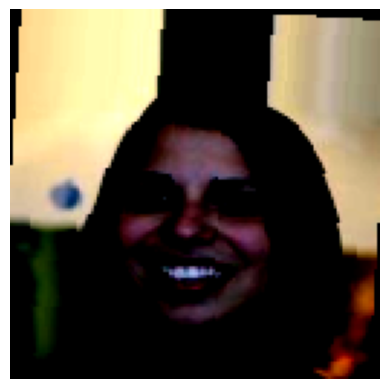

tensor(2)


In [424]:
for images, labels in train_loader:
    print(images.shape) 
    
    img = images[0].permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    print(labels[0])
    break

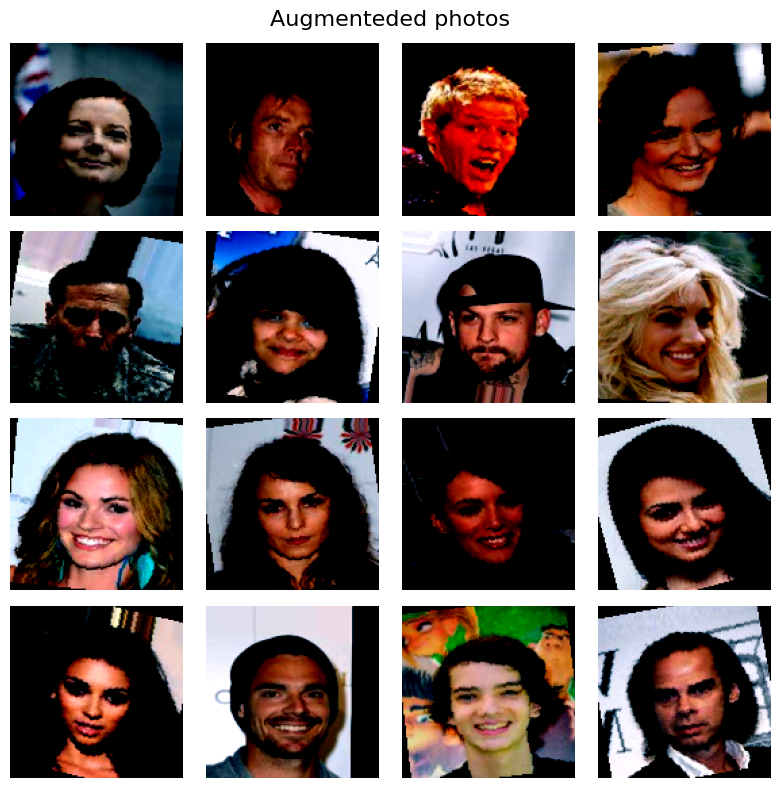

In [427]:
for images, labels in train_loader:
    images = images[:16]
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle("Augmenteded photos", fontsize=16)
    for i, ax in enumerate(axes.flat):
        
        img = images[i].permute(1, 2, 0)
        img = torch.clamp(img, 0, 1)
        ax.imshow(img)
        ax.axis('off')
        
    plt.tight_layout()
    plt.axis('off')
    plt.show()
    break